In [1]:
import jsonlines as jsonl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with jsonl.open('dota2_metrics.jsonl') as f:
# with jsonl.open('cod_metrics.jsonl') as f:
    metrics = [e for e in f]

In [3]:
metrics_df = pd.DataFrame([{(outerKey, innerKey): values for outerKey, innerDict in dictionary.items() for innerKey, values in innerDict.items()} for dictionary in metrics])

('point_seperate_messages', 'distilbert/distilroberta-base', np.float64(5e-06), '2024-09-04 09:57')
metrics  bal_acc  mean    0.647177
                  std     0.018299
         auc      mean    0.710810
                  std     0.017464
         prec     mean    0.101808
                  std     0.019078
         rec      mean    0.534632
                  std     0.072763
Name: 10, dtype: float64
('point_seperate_messages', '../models/mlm/distilroberta-base_blob_input-2024-05-14_21-02-48/checkpoint-267930', np.float64(5e-06), '2024-09-04 12:27')
metrics  bal_acc  mean    0.648286
                  std     0.047900
         auc      mean    0.744170
                  std     0.030787
         prec     mean    0.112751
                  std     0.031079
         rec      mean    0.512987
                  std     0.164891
Name: 13, dtype: float64
('current_player_only_point_sep', '../models/mlm/distilroberta-base_blob_input-2024-05-14_21-02-48/checkpoint-267930', np.float64(4e-06), 

/tmp/ipykernel_206756/636865805.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


('add_special_tokens', '../models/mlm/distilroberta-base_player_tokens_blob_input-2024-05-17_17-55-51/checkpoint-276950', np.float64(6e-06), '2024-09-04 00:27')
metrics  bal_acc  mean    0.728447
                  std     0.047202
         auc      mean    0.827215
                  std     0.055186
         prec     mean    0.181665
                  std     0.033862
         rec      mean    0.585137
                  std     0.084149
Name: 19, dtype: float64
('current_player_only_special_tokens', '../models/mlm/distilroberta-base_player_tokens_blob_input-2024-05-17_17-55-51/checkpoint-276950', np.float64(3e-06), '2024-09-04 02:56')
metrics  bal_acc  mean    0.720926
                  std     0.039812
         auc      mean    0.814342
                  std     0.047524
         prec     mean    0.125288
                  std     0.024203
         rec      mean    0.681818
                  std     0.054923
Name: 19, dtype: float64


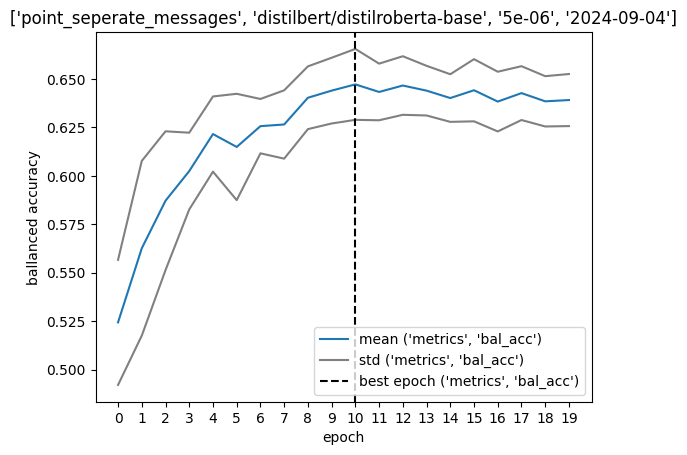

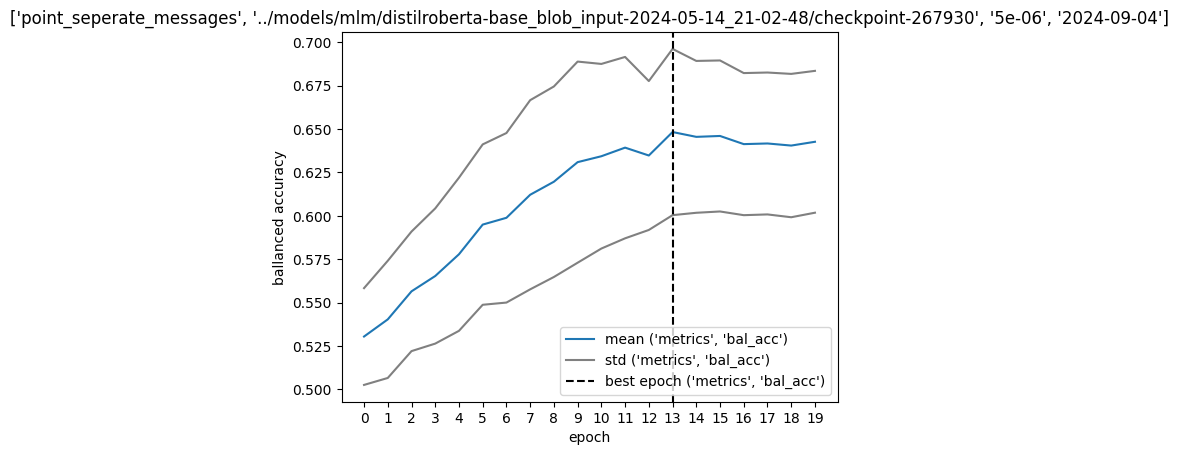

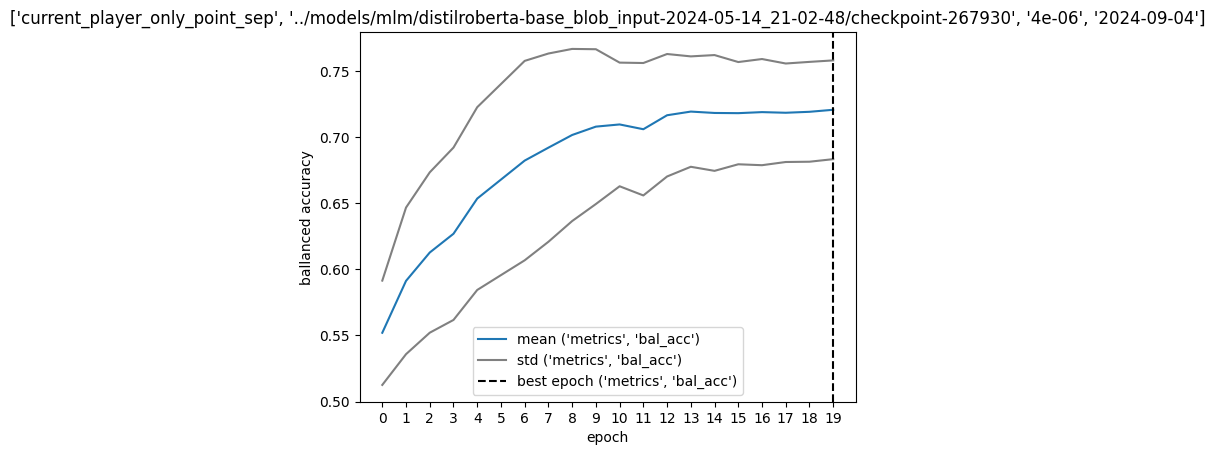

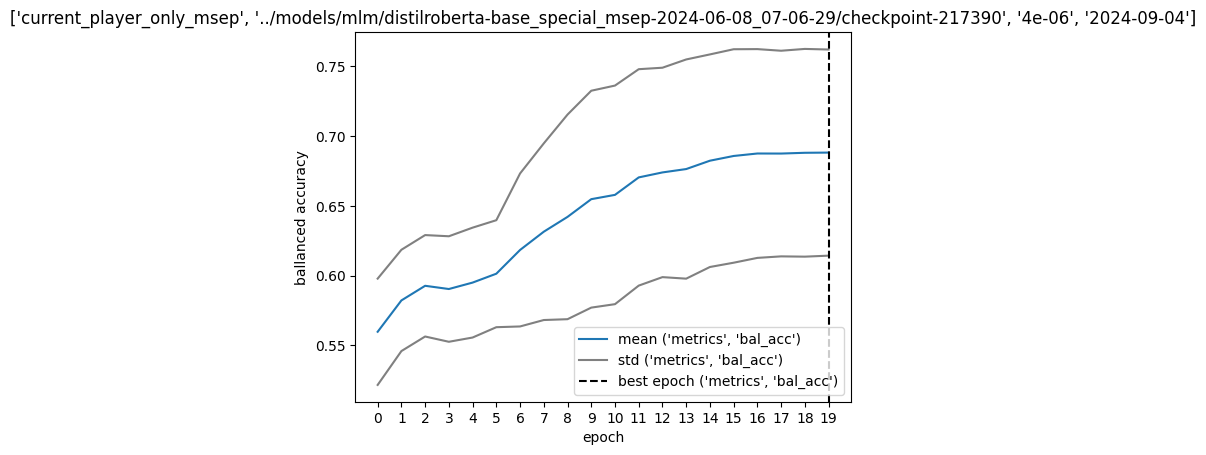

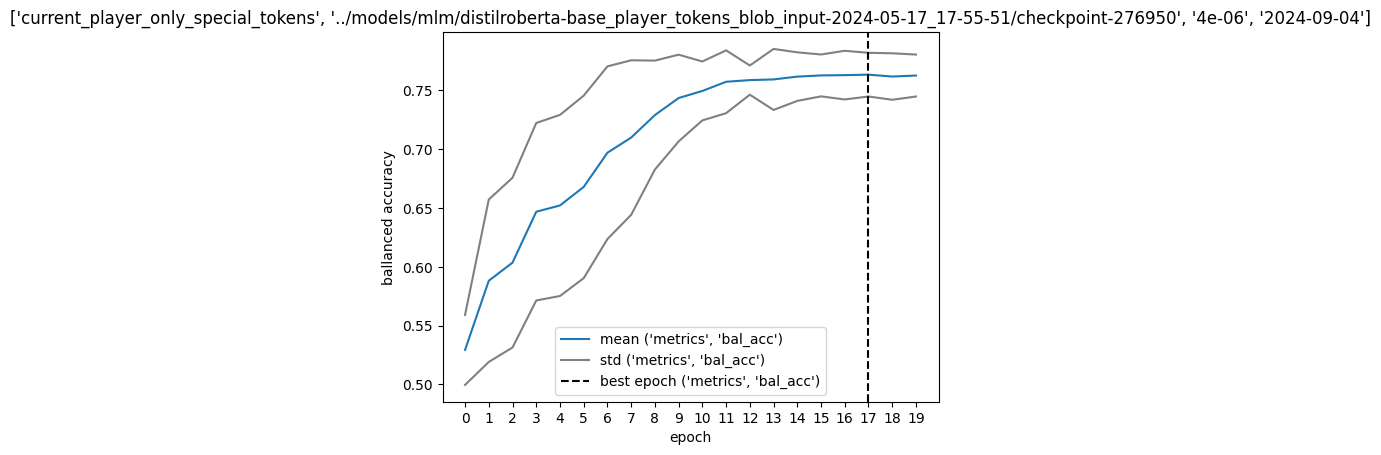

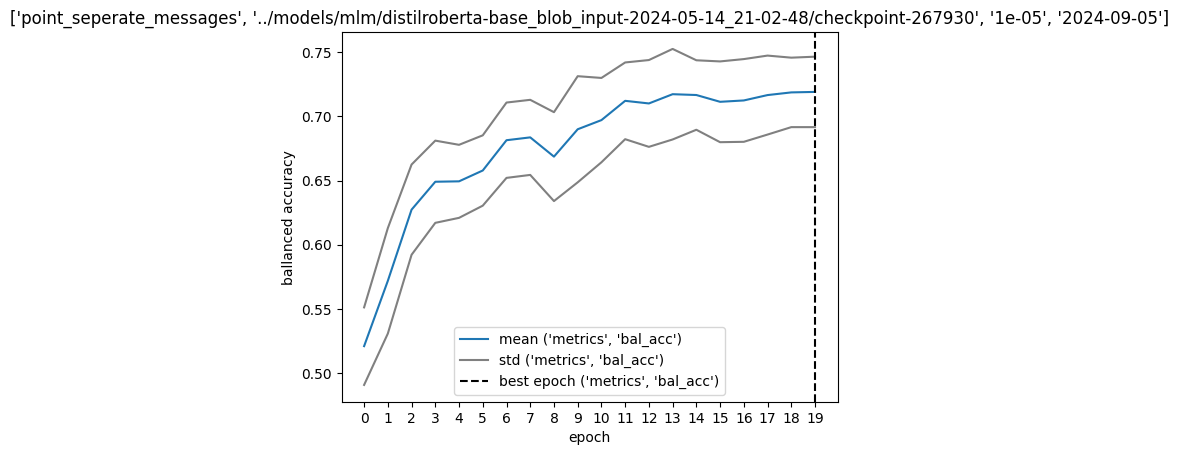

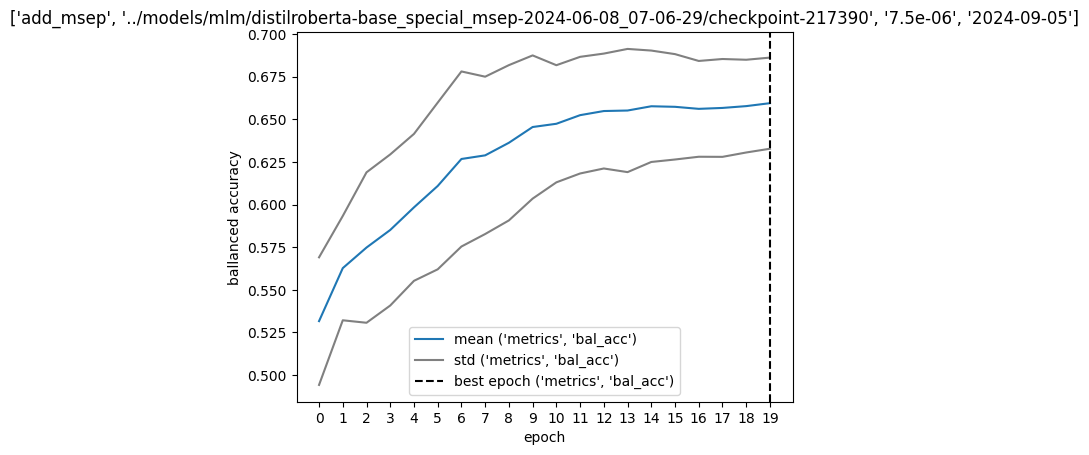

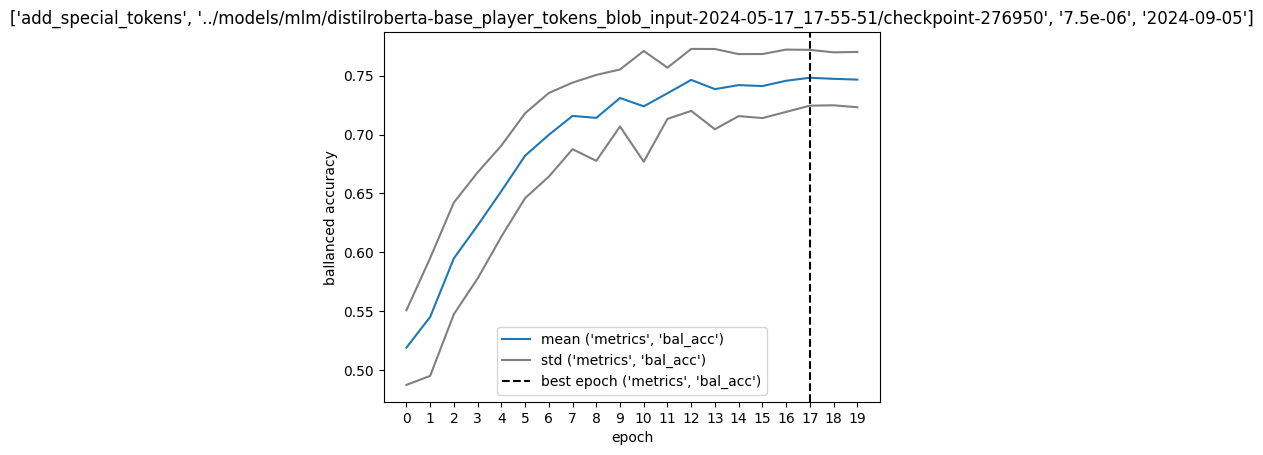

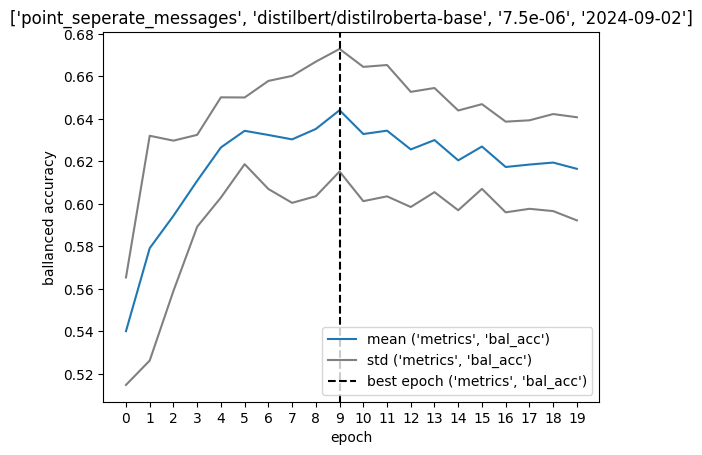

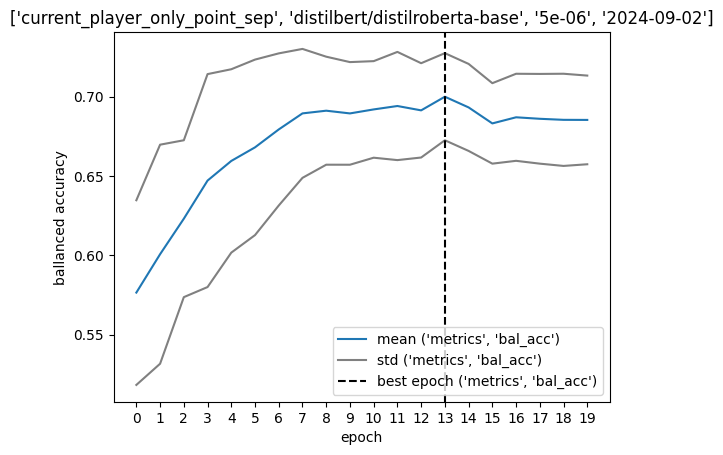

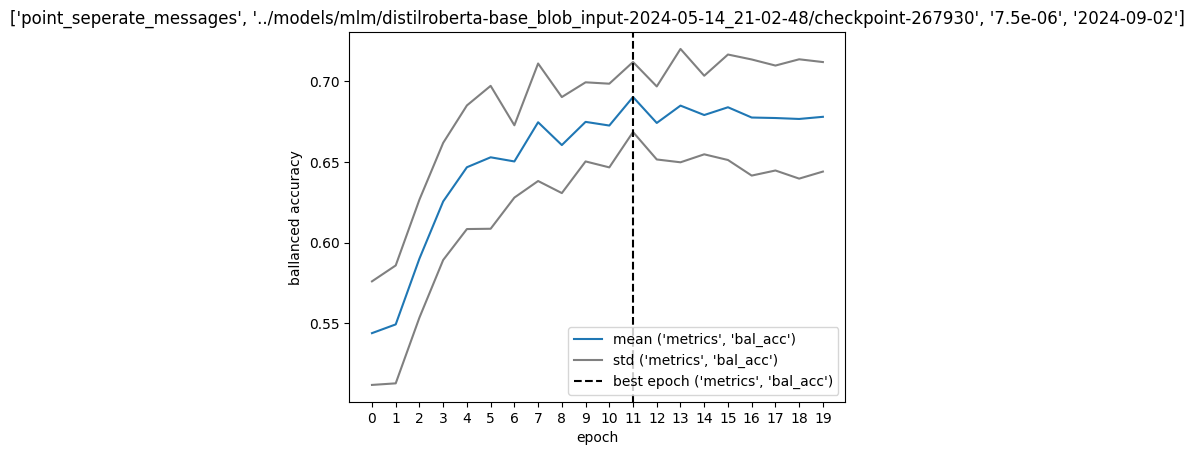

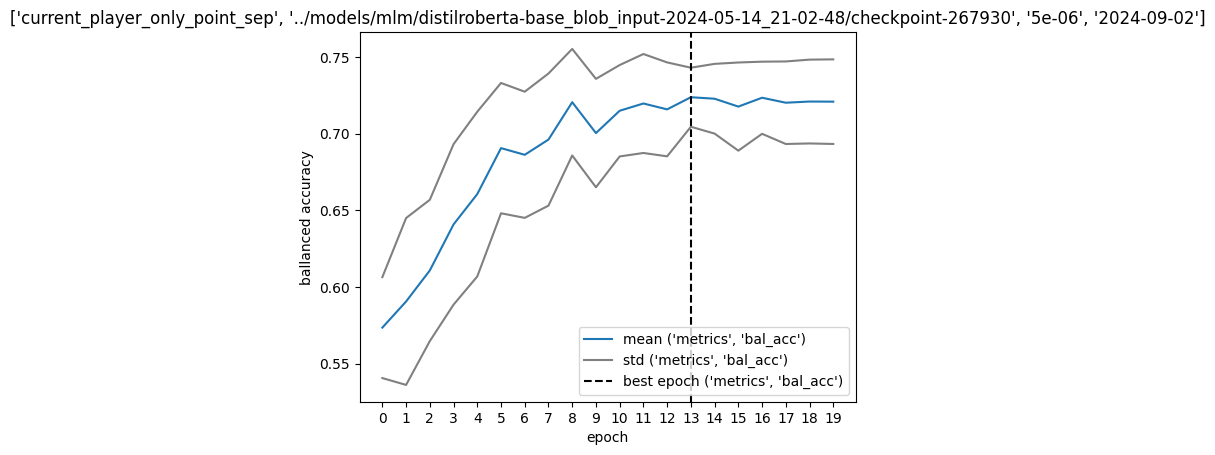

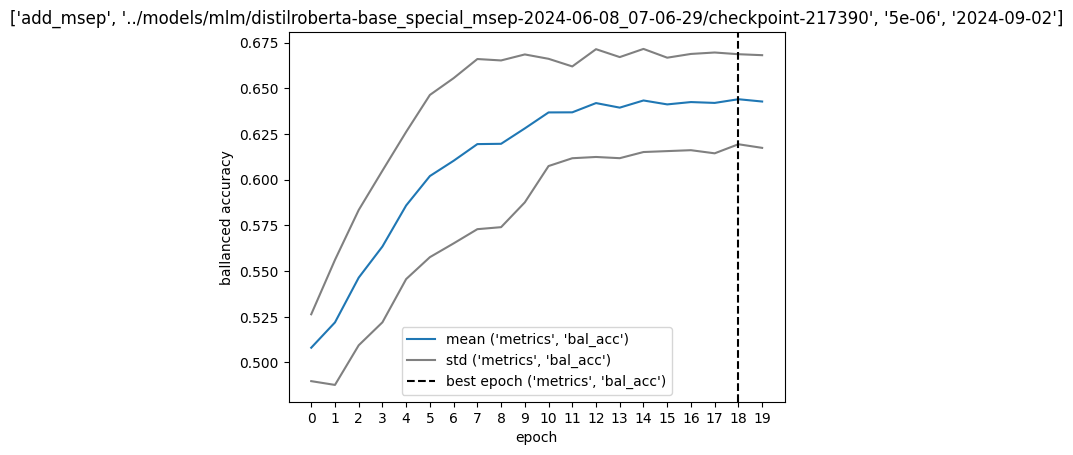

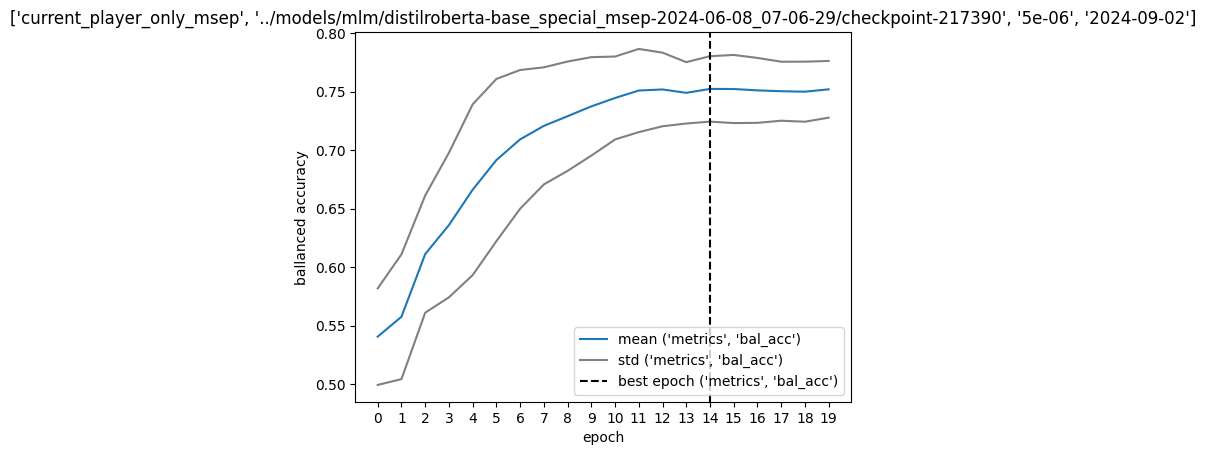

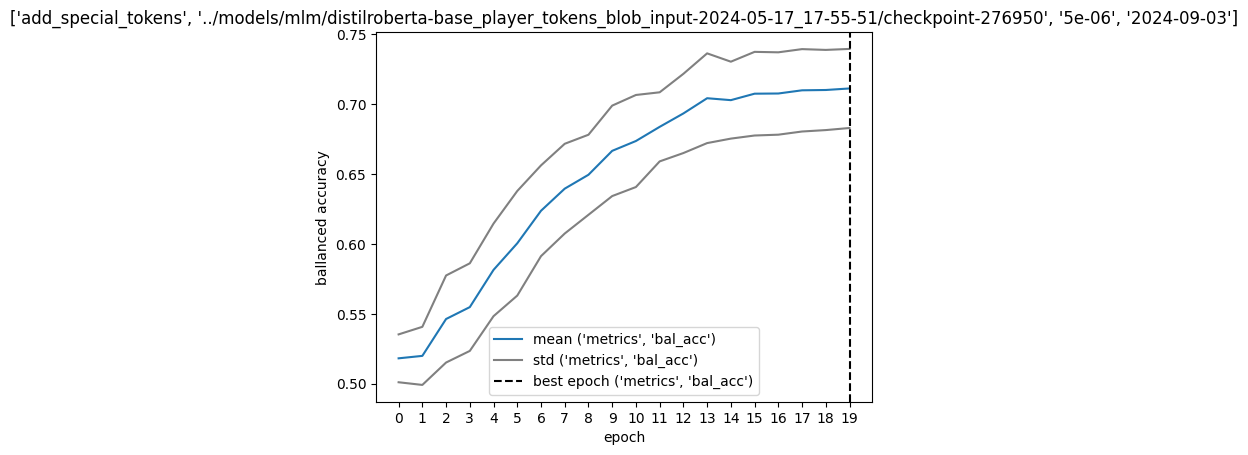

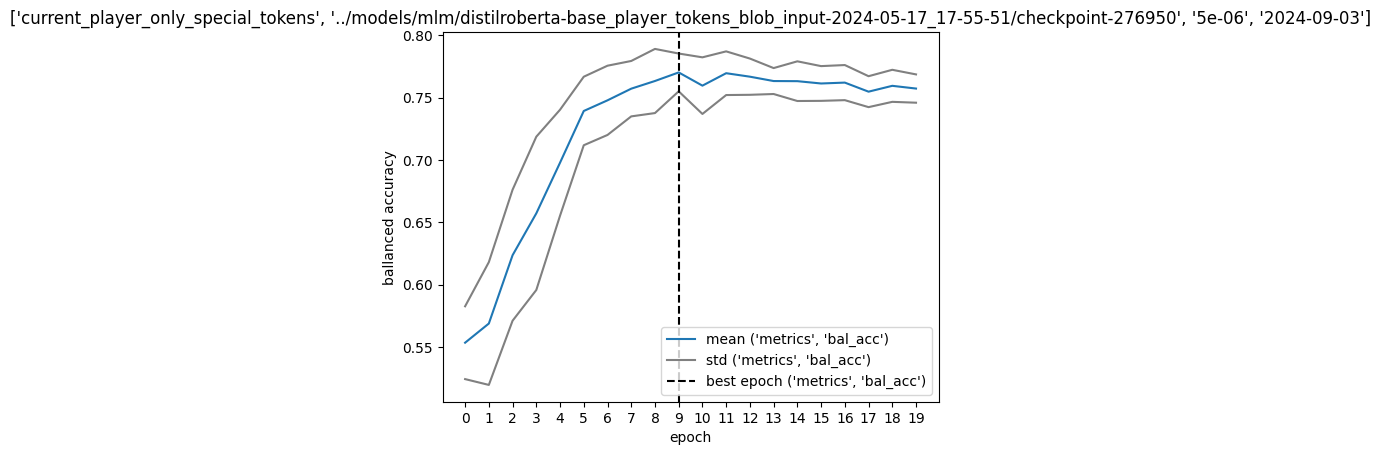

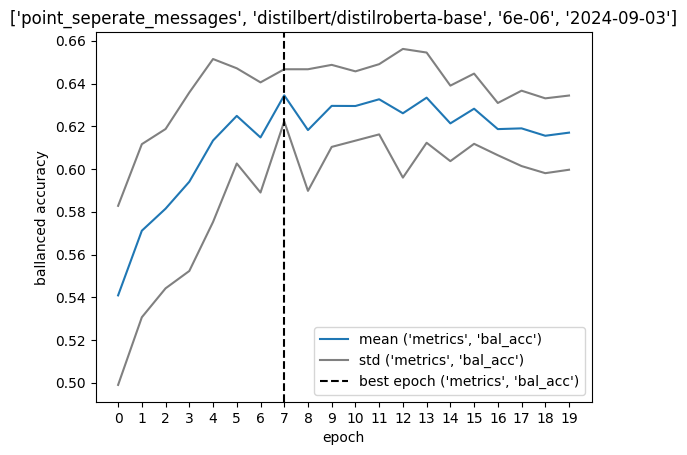

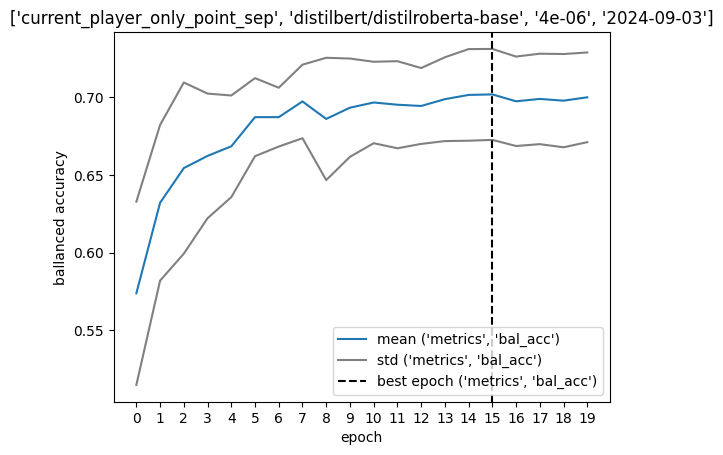

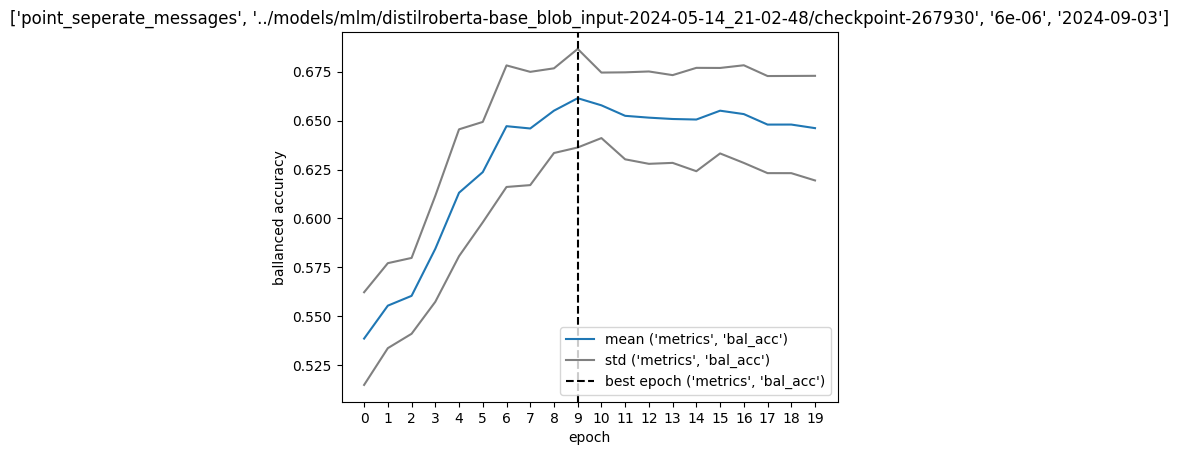

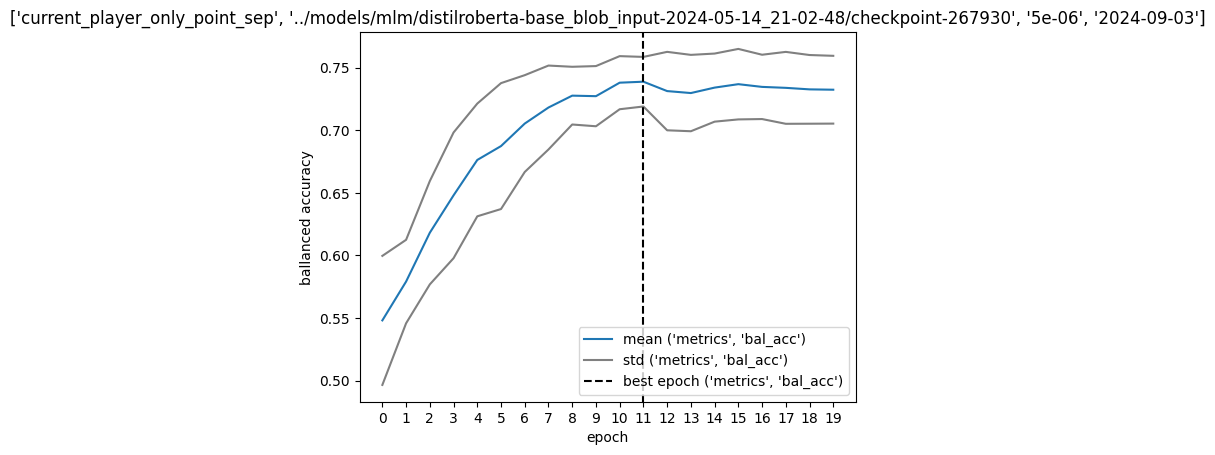

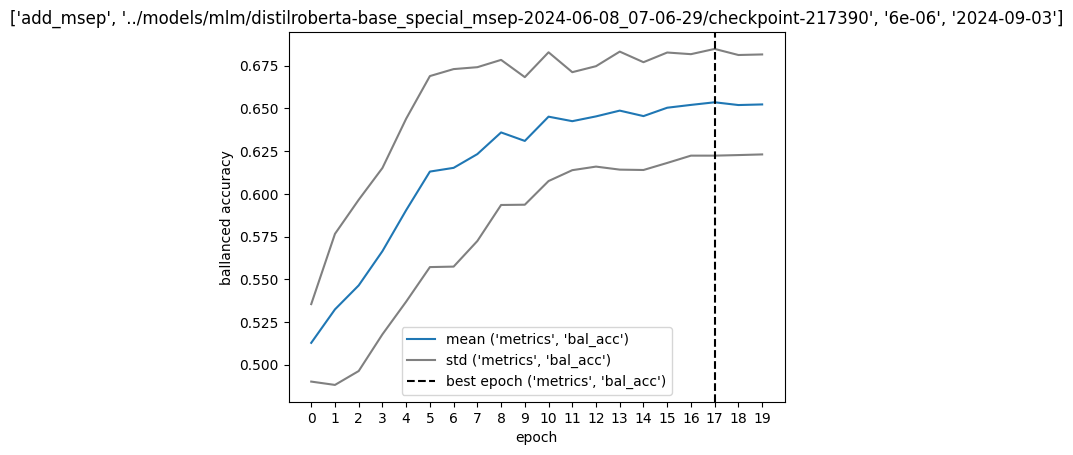

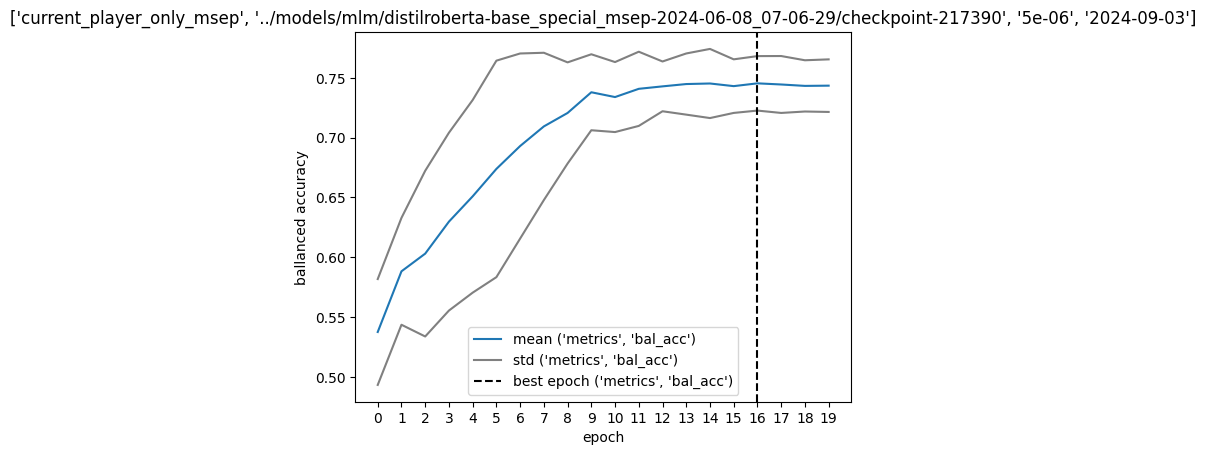

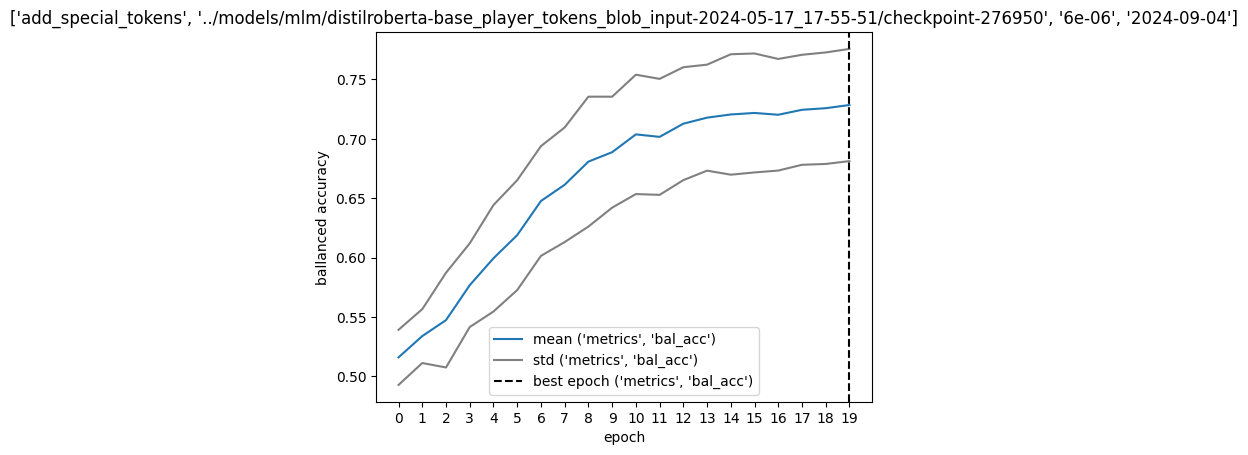

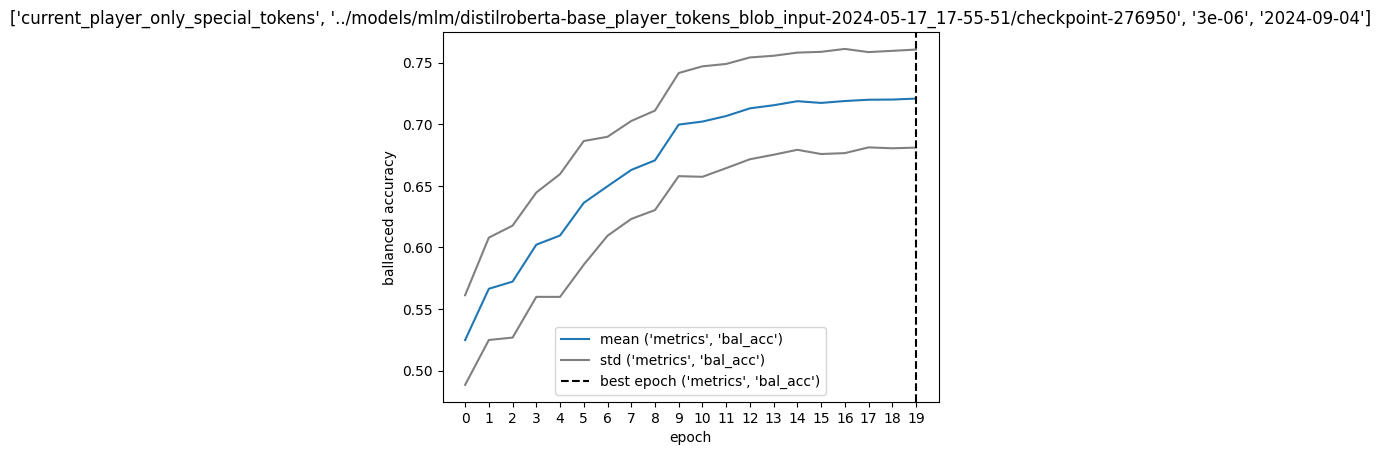

In [10]:
to_plot = [('metrics', 'bal_acc')]#, ('metrics', 'train_loss')]#, ('metrics', 'test_loss')]
to_group = [('metadata', 'message_concatenator'), ('metadata', 'base_model'), ('metadata', 'lr'), ('metadata', 'experiment_start')]
to_agg = [('metrics', 'epoch')]
metric_cols = [ (t, m) for t in ['metrics'] for m in ['bal_acc', 'auc', 'prec', 'rec'] ]

for group, subdf in metrics_df.groupby(to_group, sort=False):
    plt.figure()

    if to_agg:
        std_mean_df = subdf[to_agg+metric_cols].groupby(to_agg).aggregate(['mean', 'std'])
        for col in to_plot:
            best_epoch = std_mean_df[(*col, 'mean')].idxmax()
            plt.plot(std_mean_df.index, std_mean_df[(*col, 'mean')], label='mean '+str(col))
            plt.plot(std_mean_df.index, std_mean_df[(*col, 'mean')]+std_mean_df[(*col, 'std')], label='std '+str(col), color='grey')
            plt.plot(std_mean_df.index, std_mean_df[(*col, 'mean')]-std_mean_df[(*col, 'std')], color='grey')

            plt.axvline(best_epoch, color='black', linestyle='--', label='best epoch '+str(col))
            plt.xticks(std_mean_df.index)
        print(group)
        print(std_mean_df.loc[best_epoch])
    else:
        for col in to_plot:
            for n, run in subdf.groupby([('metadata', 'run')]):
                dat = run[col].tolist()
                plt.plot(dat, label=str(n[0]), alpha=.4)
            plt.xticks(range(len(dat)))

    plt.title(str([str(g).split()[0] for g in group]))
    plt.ylabel('ballanced accuracy')
    plt.xlabel('epoch')
    plt.legend()